# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  https://www.kaggle.com/datasets/laotse/credit-risk-dataset
2. Deskripsi : Dataset ini berisi informasi peminjam kredit yang digunakan
untuk memprediksi risiko gagal bayar (loan_status).
Fitur yang tersedia meliputi usia, pendapatan tahunan,
kepemilikan rumah, riwayat kredit, dan jumlah pinjaman.

   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [8]:
#Type your code here
# Cell 2: Data Loading
df = pd.read_csv('credit_risk_dataset.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (32581, 12)

First 5 rows:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [10]:
#Type your code here
# Cell 3: EDA - Basic Information
print("=== DATASET INFO ===")
print(df.info())
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DUPLICATED ROWS ===")
print("Duplicates:", df.duplicated().sum())
print("\n=== STATISTICAL SUMMARY ===")
display(df.describe())

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None

=== 

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


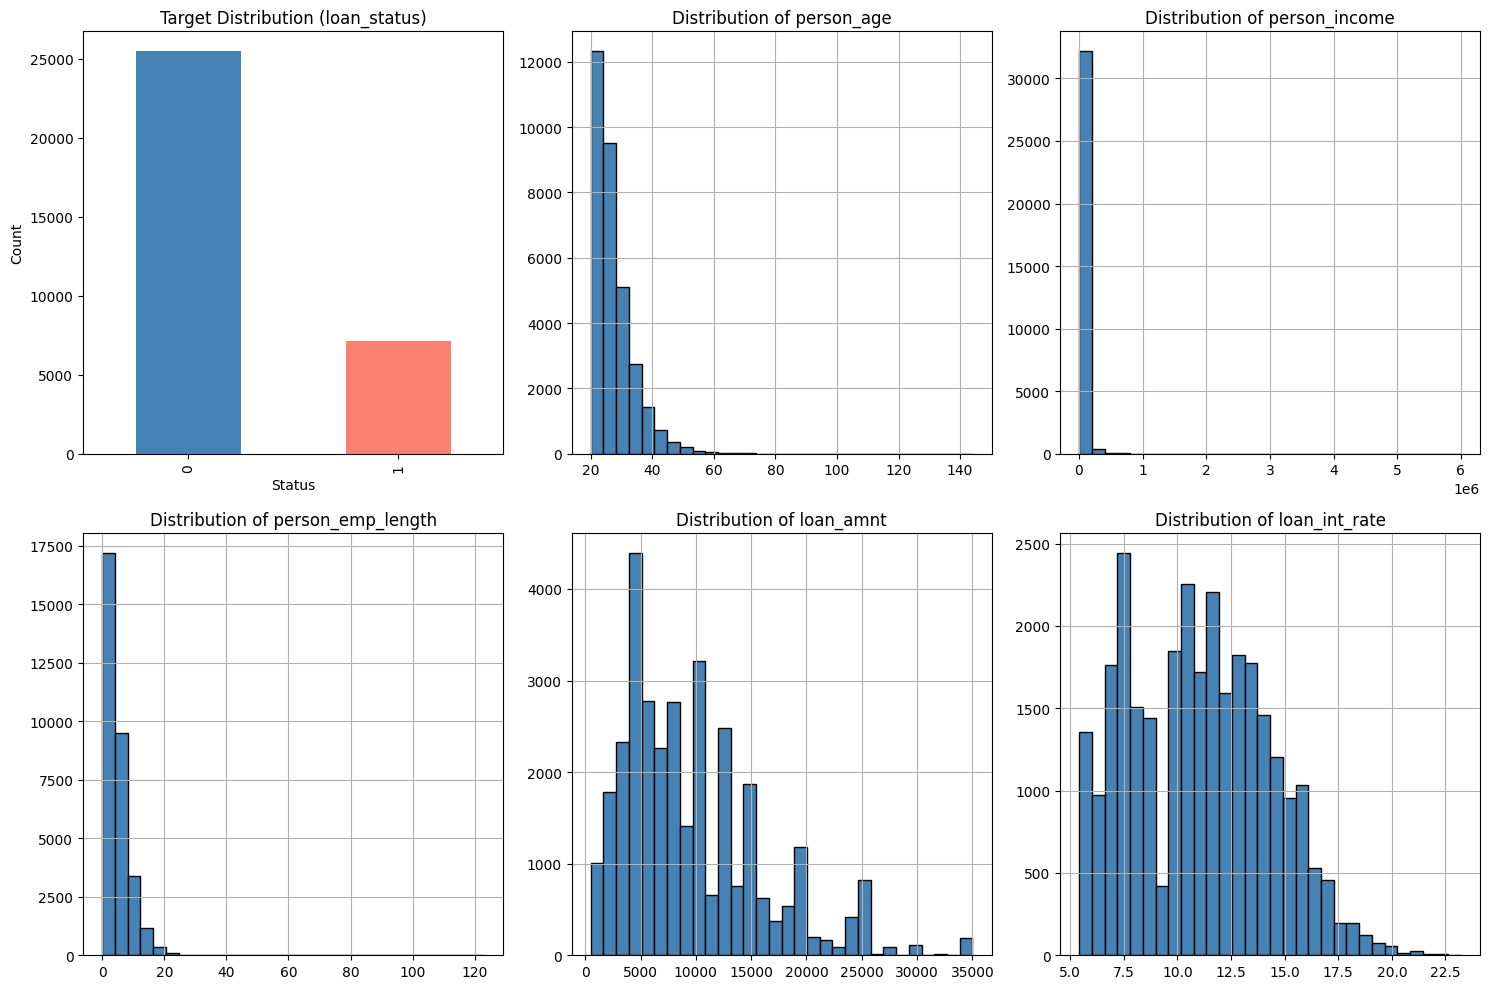

Distribution plot saved!


In [11]:
# Cell 4: EDA - Distribution Analysis
import os
os.makedirs('../preprocessing', exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Distribusi target
df['loan_status'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','salmon'])
axes[0,0].set_title('Target Distribution (loan_status)')
axes[0,0].set_xlabel('Status')
axes[0,0].set_ylabel('Count')

# Distribusi 5 fitur numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'loan_status']

for i, col in enumerate(numeric_cols[:5]):
    row, col_idx = divmod(i+1, 3)
    df[col].hist(ax=axes[row, col_idx], bins=30, color='steelblue', edgecolor='black')
    axes[row, col_idx].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.savefig('eda_distribution.png')
plt.show()
print("Distribution plot saved!")

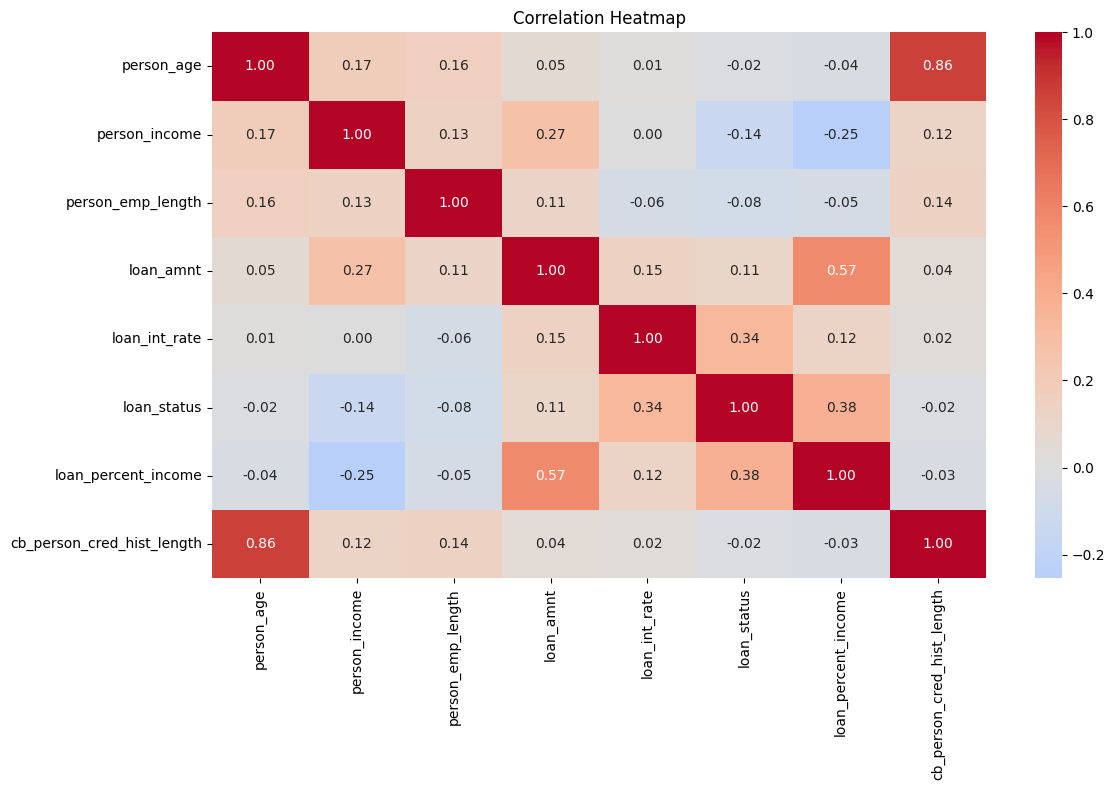

Correlation heatmap saved!


In [12]:
# Cell 5: EDA - Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation.png')
plt.show()
print("Correlation heatmap saved!")

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [14]:
# Cell 6: Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


# 1. Handle Missing Values
print("=== BEFORE - Missing Values ===")
print(df.isnull().sum())

df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)

print("\n=== AFTER - Missing Values ===")
print(df.isnull().sum())

# 2. Remove Duplicates
df.drop_duplicates(inplace=True)
print(f"\nShape after removing duplicates: {df.shape}")

# 3. Handle Outliers (IQR method)
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['person_age', 'person_income', 'person_emp_length']:
    df = remove_outliers_iqr(df, col)

print(f"Shape after removing outliers: {df.shape}")

# 4. Encode Categorical Columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

print(f"\nCategorical columns encoded: {categorical_cols}")

# 5. Feature Scaling
scaler = StandardScaler()
feature_cols = [c for c in df.columns if c != 'loan_status']
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("\nScaling completed!")
display(df.head())
display(df.head())

# 6. Split Train/Test
X = df.drop(columns=['loan_status'])
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Simpan ke CSV
import os
os.makedirs('credit_risk_dataset_preprocessing', exist_ok=True)

train = X_train.copy()
train['loan_status'] = y_train.values
train.to_csv('credit_risk_dataset_preprocessing/train.csv', index=False)

test = X_test.copy()
test['loan_status'] = y_test.values
test.to_csv('credit_risk_dataset_preprocessing/test.csv', index=False)

print("✅ Train dan test CSV berhasil disimpan!")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

=== BEFORE - Missing Values ===
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

=== AFTER - Missing Values ===
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Shape after removing duplicates: (28844, 12)
Shape after removing outliers: (27612, 12)

Categorical columns encoded: []

Scaling completed!


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,-1.281881,-1.818391,0.174584,0.267210,-0.875919,-0.187326,-1.372927,0.042366,0,-0.705905,-0.464656,-0.971777
2,-0.307066,-1.818391,-1.231661,-1.026362,0.276970,0.674603,-0.617014,0.606364,1,3.672607,-0.464656,-0.644740
3,-0.794473,0.315832,0.877706,-0.056183,0.276970,0.674603,4.338411,1.375748,1,3.299968,-0.464656,-0.971777
4,-0.550770,-0.107958,0.877706,1.237390,0.276970,0.674603,4.338411,1.062778,1,3.486288,2.152128,-0.317704
5,-1.281881,-1.806937,0.174584,-0.702969,1.429859,-1.049255,-1.120956,-1.261675,1,0.691492,-0.464656,-0.971777


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,-1.281881,-1.818391,0.174584,0.267210,-0.875919,-0.187326,-1.372927,0.042366,0,-0.705905,-0.464656,-0.971777
2,-0.307066,-1.818391,-1.231661,-1.026362,0.276970,0.674603,-0.617014,0.606364,1,3.672607,-0.464656,-0.644740
3,-0.794473,0.315832,0.877706,-0.056183,0.276970,0.674603,4.338411,1.375748,1,3.299968,-0.464656,-0.971777
4,-0.550770,-0.107958,0.877706,1.237390,0.276970,0.674603,4.338411,1.062778,1,3.486288,2.152128,-0.317704
5,-1.281881,-1.806937,0.174584,-0.702969,1.429859,-1.049255,-1.120956,-1.261675,1,0.691492,-0.464656,-0.971777


✅ Train dan test CSV berhasil disimpan!
Train shape: (22089, 12)
Test shape: (5523, 12)
